<a href="https://colab.research.google.com/github/bhalashri/CNN/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# Class names
class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

# Load dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Build CNN
model = models.Sequential([

    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(32, 32, 3)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        128, (3, 3),
        activation='relu'
    ),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

# Display architecture
model.summary()

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

# Evaluate
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=2
)

print("\nTest Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'],
         label='Training Accuracy')
plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],
         label='Training Loss')
plt.plot(history.history['val_loss'],
         label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Prediction
predictions = model.predict(x_test)
predicted_classes = predictions.argmax(axis=1)

# Display predictions
plt.figure(figsize=(12, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i])

    predicted = class_names[predicted_classes[i]]
    actual = class_names[y_test[i][0]]

    plt.title(
        f"Pred: {predicted}\nActual: {actual}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

  5398528/170498071 ━━━━━━━━━━━━━━━━━━━━ 30:03 11us/step

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)

Pixel values normalized between 0 and 1
Labels converted to one-hot encoding


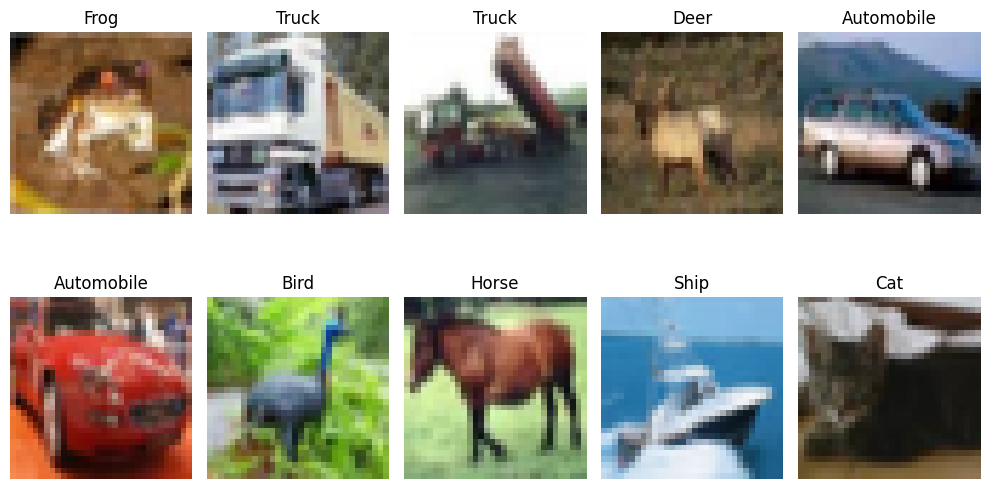


CNN MODEL ARCHITECTURE


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)


Model compiled successfully
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 88ms/step - accuracy: 0.3660 - loss: 1.7157 - val_accuracy: 0.5095 - val_loss: 1.3787
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.5139 - loss: 1.3582 - val_accuracy: 0.5657 - val_loss: 1.1911
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 87ms/step - accuracy: 0.5806 - loss: 1.1958 - val_accuracy: 0.6180 - val_loss: 1.0741
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 89ms/step - accuracy: 0.6238 - loss: 1.0766 - val_accuracy: 0.6608 - val_loss: 0.9652
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 87ms/step - accuracy: 0.6549 - loss: 0.9928 - val_accuracy: 0.6658 - val_loss: 0.9419
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 88ms/step - accuracy: 0.6862 - loss: 0.9021 - val_accuracy: 0.6854 - val_loss: 0.9028
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.7053 - loss: 0.8456 - val_accuracy: 0.7033 - val_loss: 0.8462
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accur

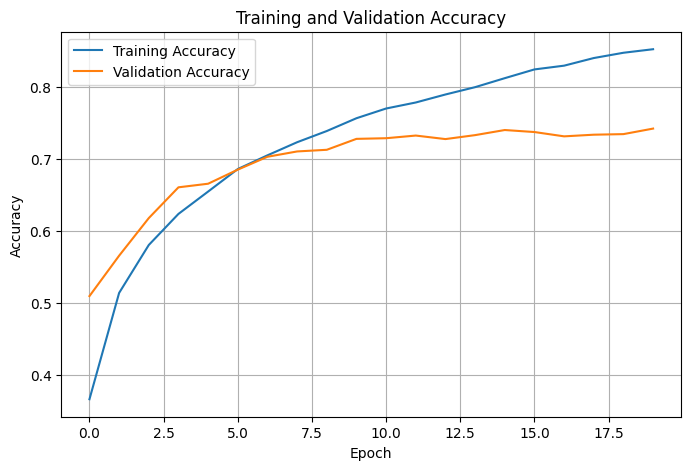

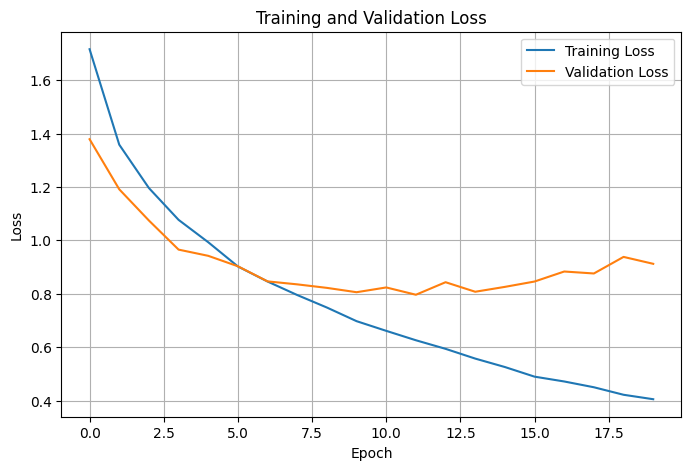

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step

PREDICTED CLASS LABELS
----------------------
Image 1 | Predicted: Cat | Actual: Cat
Image 2 | Predicted: Ship | Actual: Ship
Image 3 | Predicted: Automobile | Actual: Ship
Image 4 | Predicted: Airplane | Actual: Airplane
Image 5 | Predicted: Deer | Actual: Frog
Image 6 | Predicted: Frog | Actual: Frog
Image 7 | Predicted: Automobile | Actual: Automobile
Image 8 | Predicted: Frog | Actual: Frog
Image 9 | Predicted: Cat | Actual: Cat
Image 10 | Predicted: Automobile | Actual: Automobile
Image 11 | Predicted: Airplane | Actual: Airplane
Image 12 | Predicted: Truck | Actual: Truck
Image 13 | Predicted: Deer | Actual: Dog
Image 14 | Predicted: Horse | Actual: Horse
Image 15 | Predicted: Truck | Actual: Truck
Image 16 | Predicted: Ship | Actual: Ship
Image 17 | Predicted: Dog | Actual: Dog
Image 18 | Predicted: Horse | Actual: Horse
Image 19 | Predicted: Ship | Actual: Ship
Image 20 | Predicted: Frog | Actual: Frog


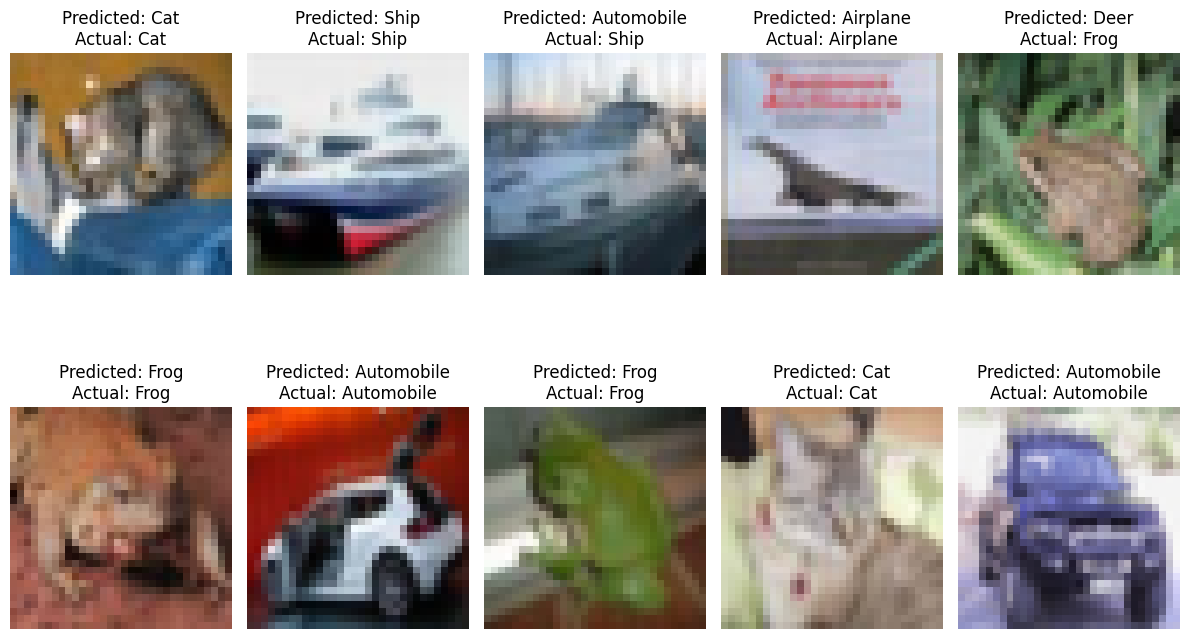

In [ ]:
# ============================================================
# CNN IMAGE CLASSIFICATION USING CIFAR-10
# ============================================================

# Import libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 1. CLASS NAMES
# ============================================================

class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]


# ============================================================
# 2. LOAD CIFAR-10 DATASET
# ============================================================

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)


# ============================================================
# 3. NORMALIZE IMAGE PIXEL VALUES
# ============================================================

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("\nPixel values normalized between 0 and 1")


# ============================================================
# 4. CONVERT LABELS TO CATEGORICAL FORMAT
# ============================================================

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Labels converted to one-hot encoding")


# ============================================================
# 5. DISPLAY SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')

plt.tight_layout()
plt.show()


# ============================================================
# 6. DESIGN CNN ARCHITECTURE
# ============================================================

model = models.Sequential([

    # Convolution Layer 1
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(32, 32, 3)
    ),

    # Max Pooling Layer 1
    layers.MaxPooling2D((2, 2)),


    # Convolution Layer 2
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    # Max Pooling Layer 2
    layers.MaxPooling2D((2, 2)),


    # Convolution Layer 3
    layers.Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),


    # Flatten
    layers.Flatten(),


    # Fully Connected Layer
    layers.Dense(
        128,
        activation='relu'
    ),


    # Dropout Layer
    layers.Dropout(0.5),


    # Softmax Output Layer
    layers.Dense(
        10,
        activation='softmax'
    )
])


# ============================================================
# 7. DISPLAY MODEL ARCHITECTURE
# ============================================================

print("\nCNN MODEL ARCHITECTURE")
model.summary()


# ============================================================
# 8. COMPILE THE MODEL
# ============================================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel compiled successfully")


# ============================================================
# 9. TRAIN THE MODEL
# ============================================================

history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)


# ============================================================
# 10. TRAINING ACCURACY
# ============================================================

training_accuracy = history.history['accuracy'][-1]

print("\nTraining Accuracy:",
      training_accuracy * 100, "%")


# ============================================================
# 11. VALIDATION ACCURACY
# ============================================================

validation_accuracy = history.history['val_accuracy'][-1]

print("Validation Accuracy:",
      validation_accuracy * 100, "%")


# ============================================================
# 12. EVALUATE MODEL ON TEST DATASET
# ============================================================

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=2
)

print("\nTest Accuracy:",
      test_accuracy * 100, "%")

print("Test Loss:",
      test_loss)


# ============================================================
# 13. ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.title('Training and Validation Accuracy')

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 14. LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Training and Validation Loss')

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 15. PREDICT CLASS LABELS
# ============================================================

predictions = model.predict(x_test)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

actual_classes = np.argmax(
    y_test,
    axis=1
)


# ============================================================
# 16. DISPLAY PREDICTED CLASS LABELS
# ============================================================

print("\nPREDICTED CLASS LABELS")
print("----------------------")

for i in range(20):

    print(
        "Image", i + 1,
        "| Predicted:",
        class_names[predicted_classes[i]],
        "| Actual:",
        class_names[actual_classes[i]]
    )


# ============================================================
# 17. DISPLAY PREDICTIONS WITH IMAGES
# ============================================================

plt.figure(figsize=(12, 8))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[i])

    predicted = class_names[predicted_classes[i]]
    actual = class_names[actual_classes[i]]

    plt.title(
        "Predicted: " + predicted +
        "\nActual: " + actual
    )

    plt.axis('off')

plt.tight_layout()
plt.show()


# ============================================================
# END OF PROGRAM
# ============================================================